In [1]:
from textblob import TextBlob
import nltk

In [2]:
import pandas as pd
uncleaned_reviews=pd.read_csv('Train.csv')
uncleaned_reviews.head()

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


In [3]:
from nltk.corpus import stopwords
stop = stopwords.words('english')
def text_cleaner(re):
    re['text']=re['text'].str.lower()
    re['text']=re['text'].str.replace(r"http\S+","",regex=True)
    re['text']=re['text'].str.replace('[^A-Za-z0-9]+',' ',regex=True)
    re['text']=re['text'].apply(lambda words:' '.join([word for word in words.split() if word not in stop]))

In [4]:
text_cleaner(uncleaned_reviews)

In [5]:
reviews=uncleaned_reviews

In [6]:
tokenizer=nltk.tokenize.WhitespaceTokenizer()
lemmatizer=nltk.stem.WordNetLemmatizer()
def lemmatize(txt):
    return [lemmatizer.lemmatize(w) for w in tokenizer.tokenize(txt)]
reviews['lemmatized-tokens']=reviews['text'].apply(lemmatize)
reviews.head()

,text,label,lemmatized-tokens
0,grew b 1965 watching loving thunderbirds mates...,0,"[grew, b, 1965, watching, loving, thunderbird,..."
1,put movie dvd player sat coke chips expectatio...,0,"[put, movie, dvd, player, sat, coke, chip, exp..."
2,people know particular time past like feel nee...,0,"[people, know, particular, time, past, like, f..."
3,even though great interest biblical movies bor...,0,"[even, though, great, interest, biblical, movi..."
4,im die hard dads army fan nothing ever change ...,1,"[im, die, hard, dad, army, fan, nothing, ever,..."


Visualising data

In [7]:
import itertools
import collections
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
tokens=list(itertools.chain(*list(reviews['lemmatized-tokens']))) #converts df column to list, uses chain to make iterable fast

In [9]:
counter=collections.Counter(tokens)

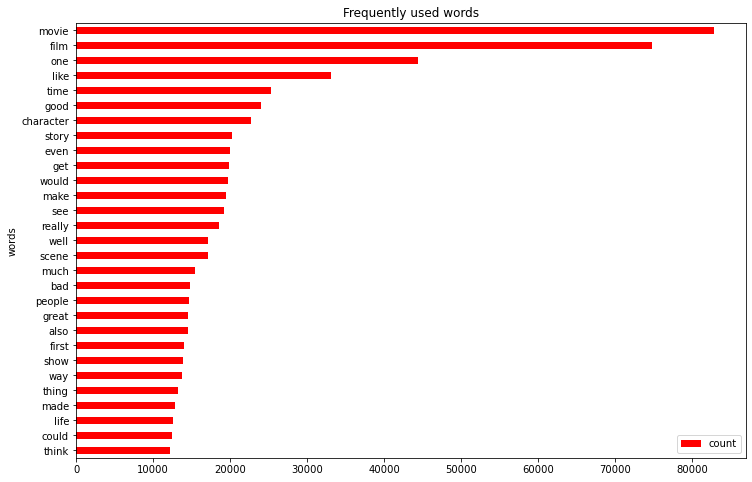

In [10]:
clean_reviews=pd.DataFrame(counter.most_common(30),columns=['words','count']) #convert to df using most common 30 words
clean_reviews=clean_reviews.iloc[1:,:]
fig,ax=plt.subplots(figsize=(12,8))
clean_reviews.sort_values(by='count').plot.barh(x='words',y='count',ax=ax,color='red')
ax.set_title("Frequently used words")
plt.show()

Using TF-IDF vectorizer for word embedding


In [132]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer()
features=tfidf.fit_transform(reviews['text'])

Training model using lightGBM classifier

In [133]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score

In [168]:
model=lgb.LGBMClassifier(max_depth=200,n_estimators=25,min_child_weight=0.0016,n_jobs=-1)
x_train=features
y_train=reviews['label']

In [169]:
model.fit(x_train,y_train)

LGBMClassifier(max_depth=200, min_child_weight=0.0016, n_estimators=25)

Testing the model accuracy on test data

In [235]:
test_review=pd.read_csv('Test.csv')

In [171]:
text_cleaner(test_review)

In [172]:
x_test=tfidf.transform(test_review['text'])

In [173]:
y_test=test_review['label']

In [175]:
pred=model.predict(x_test)

In [176]:
print('Accuracy score on test data',accuracy_score(y_test,pred))

Accuracy score on test data 0.8058


In [221]:
print('classification report:')
print(classification_report(y_test,pred))

classification report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      2495
           1       0.79      0.83      0.81      2505

    accuracy                           0.81      5000
   macro avg       0.81      0.81      0.81      5000
weighted avg       0.81      0.81      0.81      5000



Visualising classification report

In [222]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [254]:
cfmatrix=confusion_matrix(y_test,pred)

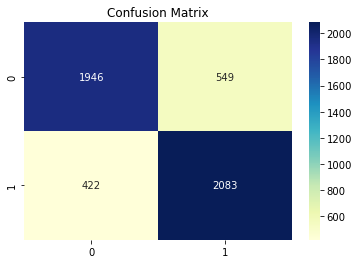

In [251]:
fig,ax=plt.subplots()
ax.set_title('Confusion Matrix')
sns.heatmap(cfmatrix,annot=True,fmt='d', cmap='YlGnBu')
plt.show()